In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score

In [2]:
df = pd.read_csv("../data/cleaned_insurance_data.csv")
df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [3]:
df["HasClaim"] = (df["TotalClaims"] > 0).astype(int)

df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]
df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

df = df.fillna(0)

In [4]:
severity_df = df[df["TotalClaims"] > 0]

In [5]:
X = severity_df.drop(columns=["TotalClaims", "HasClaim"])
y = severity_df["TotalClaims"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train.select_dtypes(include=np.number), y_train)

pred = model.predict(X_test.select_dtypes(include=np.number))

In [8]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 7.854681433329847e-12
R2: 1.0


In [9]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train.select_dtypes(include=np.number), y_train)

rf_pred = rf.predict(X_test.select_dtypes(include=np.number))

print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))

RMSE: 171.5120265438713
R2: 0.9991683033802864


In [10]:
X = df.drop(columns=["HasClaim", "TotalClaims"])
y = df["HasClaim"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)

clf.fit(
    X_train.select_dtypes(include=np.number),
    y_train
)

pred = clf.predict(X_test.select_dtypes(include=np.number))

In [13]:
print("Accuracy:", accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred))

Accuracy: 1.0
F1: 1.0


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100)

rf_clf.fit(
    X_train.select_dtypes(include=np.number),
    y_train
)

rf_pred = rf_clf.predict(X_test.select_dtypes(include=np.number))

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

Accuracy: 1.0
F1: 1.0


In [15]:
df["PredictedClaimProb"] = rf_clf.predict_proba(
    X.select_dtypes(include=np.number)
)[:, 1]

In [16]:
df["PredictedPremium"] = (
    df["PredictedClaimProb"] * df["TotalClaims"].mean()
)

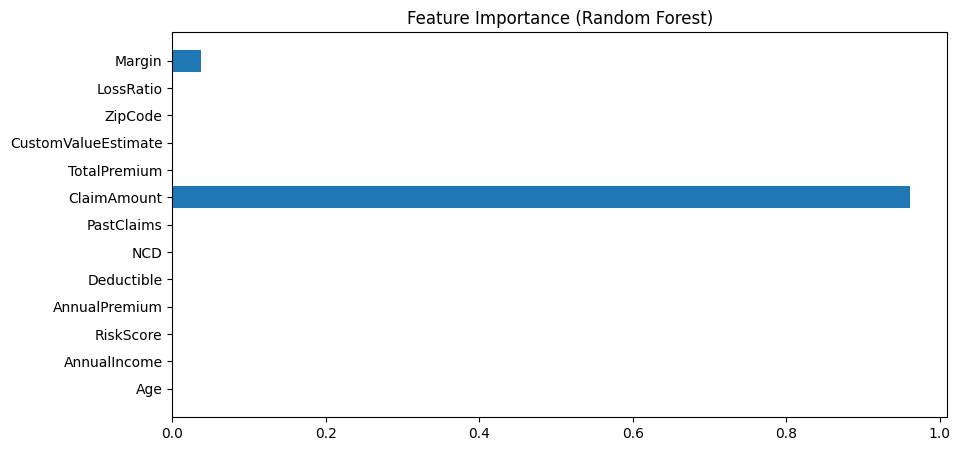

In [17]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_

features = X.select_dtypes(include=np.number).columns

plt.figure(figsize=(10,5))
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [ ]:
!pip install shap

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(
    X_test.select_dtypes(include=np.number)
)

shap.summary_plot(shap_values, X_test.select_dtypes(include=np.number))